In [2]:
from matplotlib.ticker import FuncFormatter, MultipleLocator
from scipy.interpolate import griddata
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

    curvatures_sub = (labels_sub, curv_in_sub, curv_rec_sub, curv_lat_sub, curv_lat_norm_sub, curv_true,
                      curv_learned, curv_learned_rotated, z_grid)
    curvatures_emp_full = (labels, curv_in, curv_lat, curv_lat_norm, curv_rec)

    points_sub = (inputs_sub, latents_sub, recons_sub)

    points = (inputs, latents, recons)

# Dimension 1

In [3]:
def plot_curvatures_single_figure(base_path, file_paths, labels, save_path, curv_type):
    n_files = len(file_paths)
    # Load latent curvatures
    latent_curvatures = []
    for path in file_paths:
        data = torch.load(base_path + path, weights_only=False)
        if curv_type == 'pullback':
            latent_curvatures.append(data['curvatures_sub'][6])
        else:
            latent_curvatures.append(data['curvatures_sub'][3])

    # Load angles and true curvature
    reference_data = torch.load(base_path + file_paths[0], weights_only=False)
    angles = reference_data['curvatures_sub'][0]
    if curv_type == 'pullback':
        true_curvature = reference_data['curvatures_sub'][5]
    else:
        true_curvature = reference_data['curvatures_sub'][1]

    # Labels and colors
    colors = ['tab:blue', 'tab:orange', 'tab:red', 'tab:purple']

    # Plot all on one axis
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(angles, true_curvature, label='Curv. on Inputs.', color='green', linestyle='--', linewidth=2)

    # Plot latent curvatures
    for i in range(n_files):
        ax.plot(angles, latent_curvatures[i], label=labels[i], color=colors[i], linewidth=2, alpha=0.8)

    # Formatting
    ax.set_xlabel('Angle')
    ax.set_ylabel('Curvature')
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
    ax.grid(False)
    ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def round_to_half(x, up=False):
    return np.ceil(x * 2) / 2 if up else np.floor(x * 2) / 2


def compute_three_tick_positions(min_val, max_val):
    min_ = round_to_half(min_val)
    max_ = round_to_half(max_val, up=True)
    mid = round_to_half((min_ + max_) / 2)
    return [min_, mid, max_]


def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    safe_denom = np.where(denominator == 0, 1e-8, denominator)
    return 100 * np.mean(np.abs(y_pred - y_true) / safe_denom)


def plot_curvatures_stacked(base_path, file_paths, labels, ground_truth, save_path):
    n_files = len(file_paths)
    learned_curvatures = []

    # Load angles and true curvature
    ref_data = torch.load(os.path.join(base_path, file_paths[0]), weights_only=False)
    angles = ref_data['curvatures_sub'][0]
    if ground_truth == "true_curvature":
        true_values = ref_data['curvatures_sub'][5]
    elif ground_truth == "emp_curv_ins":
        true_values = ref_data['curvatures_sub'][1]
    else:
        raise NotImplementedError

    # Load all learned curvatures
    for path in file_paths:
        data = torch.load(os.path.join(base_path, path), weights_only=False)
        if ground_truth == "true_curvature":
            learned_curvatures.append(data['curvatures_sub'][6])
        elif ground_truth == "emp_curv_ins":
            learned_curvatures.append(data['curvatures_sub'][3])
        else:
            raise NotImplementedError

    print("true curv", true_values)
    print("learned curv", learned_curvatures)

    # Global y-limits and ticks
    all_curvs = [true_values] + learned_curvatures
    y_min = min(c.min() for c in all_curvs)
    y_max = max(c.max() for c in all_curvs)
    yticks = compute_three_tick_positions(y_min, y_max)

    fig, axes = plt.subplots(nrows=n_files, ncols=1, figsize=(6, 2 * n_files), sharex=True)
    if n_files == 1:
        axes = [axes]

    tab10 = list(plt.cm.tab10.colors)
    tab10.pop(2)  # remove green
    color_cycle = tab10

    if ground_truth == "true_curvature":
        lwidth_true = 2
        lwidth_lat = 1.8
        label_true = "True Curvature"
        label_lat = "Learned Curvature"
        lstyle_true = '--'
    elif ground_truth == "emp_curv_ins":
        lwidth_true = 0.8
        lwidth_lat = 0.8
        label_true = "Curvature on Inputs"
        label_lat = "Curvature on Latents"
        lstyle_true = '-'
    else:
        raise NotImplementedError

    for i, (ax, learned, label) in enumerate(zip(axes, learned_curvatures, labels)):
        ax.plot(angles, true_values, label=label_true, color='green', linestyle=lstyle_true, linewidth=lwidth_true)
        ax.plot(angles, learned, label=f'{label_lat}.\n {label}', color=color_cycle[i % len(color_cycle)],
                linewidth=lwidth_lat)

        # Metrics
        mse_val = np.mean((learned - true_values) ** 2)
        smape_val = smape(true_values, learned)
        ax.text(0.01, 0.95, f"MSE = {mse_val:.2f}\nSMAPE = {smape_val:.2f}%",
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor='white', edgecolor='gray', alpha=0.8))

        ax.set_ylim(yticks[0], yticks[2])
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{t:.1f}" if t % 1 else f"{int(t)}" for t in yticks])
        ax.set_ylabel('Curvature', fontsize=10)
        ax.legend(loc='upper right', fontsize=8)

        if i == n_files - 1:
            ax.set_xlabel('Angle', fontsize=10)
            ax.set_xticks([0, np.pi, 2 * np.pi])
            ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
        else:
            ax.set_xticklabels([])

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# Dimension 2

In [4]:
def plot_curvatures_2d(base_path, file_paths, save_path, plot_empirical, plot_pullback, dataset_name, show_plot):
    os.makedirs(save_path, exist_ok=True)

    grid_res = 100
    if dataset_name in {"sphere", "s2_synthetic", "sphere_high_dim", "nested_spheres", "nested_spheres_high_dim"}:
        grid_x, grid_y = np.meshgrid(
            np.linspace(0, np.pi, int(grid_res // 2)),
            np.linspace(0, 2 * np.pi, grid_res)
        )
    else:
        grid_x, grid_y = np.meshgrid(
            np.linspace(0, 2 * np.pi, grid_res),
            np.linspace(0, 2 * np.pi, grid_res)
        )

    def interpolate(lbls, values):
        return griddata(lbls, values, (grid_x, grid_y), method="cubic")

    def pi_formatter(x, pos):
        if np.isclose(x, 0):
            return "0"
        elif np.isclose(x, np.pi / 2):
            return r"$\frac{\pi}{2}$"
        elif np.isclose(x, np.pi):
            return r"$\pi$"
        elif np.isclose(x, 2 * np.pi):
            return r"$2\pi$"
        else:
            return ""

    def plot_surface(surface, fname, show_plot):
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(1, 1, 1, projection='3d')
        surf = ax.plot_surface(grid_x, grid_y, surface, cmap='viridis')

        ax.xaxis.set_major_locator(MultipleLocator(np.pi / 2))
        ax.yaxis.set_major_locator(MultipleLocator(np.pi))
        ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
        ax.yaxis.set_major_formatter(FuncFormatter(pi_formatter))

        plt.tight_layout()
        plt.savefig(os.path.join(save_path, fname), dpi=300, bbox_inches='tight')
        if show_plot:
            plt.show()
        else:
            plt.close(fig)

    # ---- plot true curvature only once from first file ----
    if plot_pullback and len(file_paths) > 0:
        first_file = os.path.join(base_path, file_paths[0])
        data_first = torch.load(first_file, weights_only=False)
        labels_sub_first = data_first['curvatures_sub'][0]
        curv_true_first = data_first['curvatures_sub'][5]
        surf_true = interpolate(labels_sub_first, curv_true_first)
        plot_surface(surf_true, f"{dataset_name}_curvplot_true_curv.png", show_plot=show_plot)

    # ---- loop over all files for learned and empirical ----
    for path in file_paths:
        data = torch.load(os.path.join(base_path, path), weights_only=False)
        base_name = os.path.splitext(os.path.basename(path))[0]

        if plot_pullback:
            labels_sub = data['curvatures_sub'][0]
            curv_learned = data['curvatures_sub'][6]
            surf_learned = interpolate(labels_sub, curv_learned)
            plot_surface(surf_learned,
                         f"{base_name}_curvplot_learned_curv.png",
                         show_plot=show_plot)

        if plot_empirical:
            labels_full = data['curvatures_emp_full'][0]
            curv_in = data['curvatures_emp_full'][1]
            curv_lat = data['curvatures_emp_full'][2]
            surf_in = interpolate(labels_full, curv_in)
            surf_lat = interpolate(labels_full, curv_lat)

            plot_surface(surf_in,
                         f"{base_name}_curvplot_emp_ins.png",
                         show_plot=show_plot)
            plot_surface(surf_lat,
                         f"{base_name}_curvplot_emp_lats.png",
                         show_plot=show_plot)


In [5]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors as mpl_colors
from sklearn.decomposition import PCA

def plot_curvature_heatmaps(base_path_curv, file_paths, save_path,
                            plot_empirical=True, plot_pullback=True,
                            dataset_name="s2_synthetic", show_plot=True):
    """
    Plots curvature heatmaps with a SINGLE, SHARED color normalization for all figures.

    The global vmin/vmax are computed from all curvature arrays that are actually plotted
    in this invocation (true curvature, empirical input/latent, learned pullback).
    """
    os.makedirs(save_path, exist_ok=True)
    color_map = 'rainbow'
    pca_dim = 2 if dataset_name == "s1_synthetic" else 3

    def _scatter_datapoints(ax, data, colors_vals=None, cmap='hsv', pca_dim=3, dot_size=2, norm=None):
        d = data.shape[1]
        if d == 1:
            sc = ax.scatter(data[:, 0], np.zeros_like(data[:, 0]),
                            c=colors_vals, cmap=cmap, norm=norm, s=dot_size, alpha=0.7)
            ax.set_yticks([])
        elif d == 2:
            sc = ax.scatter(data[:, 0], data[:, 1],
                            c=colors_vals, cmap=cmap, norm=norm, s=dot_size, alpha=0.7)
        else:
            data = PCA(n_components=pca_dim).fit_transform(data)
            if pca_dim == 2:
                sc = ax.scatter(data[:, 0], data[:, 1],
                                c=colors_vals, cmap=cmap, norm=norm, s=dot_size, alpha=0.7)
            else:
                sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2],
                                c=colors_vals, cmap=cmap, norm=norm, s=dot_size, alpha=0.7)
        ax.set_xlim(data[:, 0].min(), data[:, 0].max())
        if data.shape[1] >= 2:
            ax.set_ylim(data[:, 1].min(), data[:, 1].max())
        if data.shape[1] >= 3 and hasattr(ax, "set_zlim"):
            ax.set_zlim(data[:, 2].min(), data[:, 2].max())
        ax.set_aspect('equal', adjustable='datalim')
        return sc

    def _angles_to_points(angles, dataset_name):
        if dataset_name in {"s2_synthetic", "sphere"}:
            # angles[:,0] = polar (colatitude), angles[:,1] = azimuth
            x = np.sin(angles[:, 0]) * np.cos(angles[:, 1])
            y = np.sin(angles[:, 0]) * np.sin(angles[:, 1])
            z = np.cos(angles[:, 0])
        else:  # t2_synthetic (torus)
            theta = angles[:, 0]
            phi = angles[:, 1]
            x = (2 - 1 * np.cos(theta)) * np.cos(phi)
            y = (2 - 1 * np.cos(theta)) * np.sin(phi)
            z = 1 * np.sin(theta)
        return np.stack([x, y, z], axis=1)

    # -------------------- pass 1: collect global vmin/vmax over all plotted arrays --------------------
    curv_values = []

    # true curvature (only once, based on the first file)
    if plot_pullback and len(file_paths) > 0:
        first_file = os.path.join(base_path_curv, file_paths[0])
        data_first = torch.load(first_file, weights_only=False)
        curv_true = np.asarray(data_first["curvatures_sub"][5])
        curv_values.append(curv_true)

    # all files
    for curv_file in file_paths:
        file_path = os.path.join(base_path_curv, curv_file)
        data = torch.load(file_path, weights_only=False)

        if plot_empirical:
            curv_in = np.asarray(data["curvatures_emp_full"][1])
            curv_lat = np.asarray(data["curvatures_emp_full"][3])
            curv_values.extend([curv_in, curv_lat])

        if plot_pullback:
            curv_learned = np.asarray(data["curvatures_sub"][6])
            curv_values.append(curv_learned)

    if len(curv_values) == 0:
        print("Nothing to plot with the given flags and files.")
        return

    vmin = np.min([np.nanmin(c) for c in curv_values])
    vmax = np.max([np.nanmax(c) for c in curv_values])

    # If you prefer symmetric normalization around 0 for signed curvature, uncomment:
    # m = max(abs(vmin), abs(vmax))
    # vmin, vmax = -m, m

    shared_norm = mpl_colors.Normalize(vmin=vmin, vmax=vmax)

    # -------------------- plotting helper using the shared norm --------------------
    def plot_heatmap(curv, points, fname, pca_dim, show_plot, dot_size=2):
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(
            1, 1, 1,
            projection='3d' if points.shape[1] >= 3 and pca_dim == 3 else None
        )
        sc = _scatter_datapoints(ax=ax, data=points, colors_vals=curv,
                                 cmap=color_map, pca_dim=pca_dim, dot_size=dot_size,
                                 norm=shared_norm)
        # Colorbar linked to the same norm/cmap
        cbar = fig.colorbar(sc, ax=ax, aspect=10, shrink=0.4, pad=-0.12)

        if hasattr(ax, "view_init"):
            if dataset_name in {"t2_synthetic", "torus"}:
                ax.view_init(elev=55, azim=-70)
        ax.set_axis_off()
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, fname), dpi=300, bbox_inches='tight', pad_inches=0)
        if show_plot:
            plt.show()
        else:
            plt.close(fig)

    # -------------------- pass 2: generate plots (now using shared_norm) --------------------
    # true curvature (only once)
    if plot_pullback and len(file_paths) > 0:
        first_file = os.path.join(base_path_curv, file_paths[0])
        data_first = torch.load(first_file, weights_only=False)
        angles = np.asarray(data_first["curvatures_sub"][8])
        points = _angles_to_points(angles, dataset_name)
        dot_size = 30
        curv_true = np.asarray(data_first["curvatures_sub"][5])
        plot_heatmap(curv_true, points, f"{dataset_name}_heatmap_true_curv.png",
                     pca_dim, show_plot=show_plot, dot_size=dot_size)

    # loop over all files
    for curv_file in file_paths:
        file_path = os.path.join(base_path_curv, curv_file)
        data = torch.load(file_path, weights_only=False)
        base_name = os.path.splitext(os.path.basename(curv_file))[0]

        if plot_empirical:
            inputs = np.asarray(data["points"][0])
            latents = np.asarray(data["points"][1])
            curv_in = np.asarray(data["curvatures_emp_full"][1])
            curv_lat = np.asarray(data["curvatures_emp_full"][3])

            plot_heatmap(curv_in, inputs,
                         f"{base_name}_heatmap_emp_ins.png",
                         pca_dim, show_plot=show_plot)
            plot_heatmap(curv_lat, latents,
                         f"{base_name}_heatmap_emp_lats.png",
                         pca_dim, show_plot=show_plot)

        if plot_pullback:
            angles = np.asarray(data["curvatures_sub"][8])
            points = _angles_to_points(angles, dataset_name)
            dot_size = 30
            curv_learned = np.asarray(data["curvatures_sub"][6])
            plot_heatmap(curv_learned, points,
                         f"{base_name}_heatmap_learned_curv.png",
                         pca_dim, show_plot=show_plot, dot_size=dot_size)


# Euclidean AE - Scrunchy

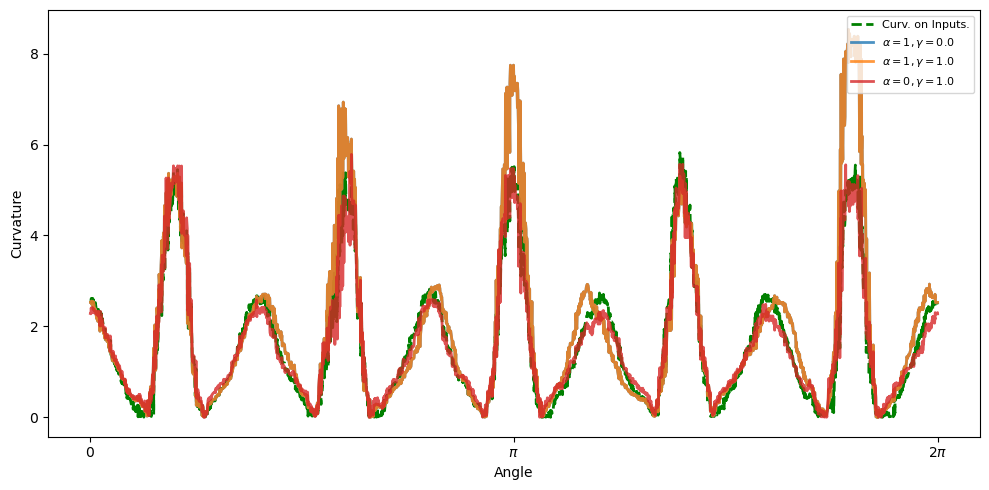

In [7]:
base_path = "OLD_notebooks_euclid_ae/curvatures/"
file_paths = [
    "curvatures_exp00_circle_low.pt",
    "curvatures_exp01_circle_low.pt",
    "curvatures_exp02_circle_low.pt",
]
labels = [r"$\alpha=1,\gamma=0.0$", r"$\alpha=1,\gamma=1.0$", r"$\alpha=0,\gamma=1.0$"]
save_path = "plots/euclid_ae/euclid_ae_flower_impact_ltopo.png"
curve_type = "empirical"


plot_curvatures_single_figure(base_path=base_path, file_paths=file_paths, labels=labels, save_path=save_path,curv_type="empirical")

# save_path = "plots/"
# dataset_name = "s1_synthetic"
# plot_empirical = True
# plot_pullback = False
# show_plot = True

# plot_curvature_heatmaps(
#     base_path_curv=base_path,
#     file_paths=file_paths,
#     save_path=save_path,
#     plot_empirical=plot_empirical,
#     plot_pullback=plot_pullback,
#     dataset_name=dataset_name,
#     show_plot=show_plot
# )


# Euclidean AE - S2_synthetic

In [6]:
base_path = "OLD_notebooks_euclid_ae/curvatures/"
file_paths = [
    "curvatures_exp00_ae_s2_synthetic_w100_b64.pt",
    "curvatures_exp06_ae_s2_synthetic_w100_b64.pt",
    "curvatures_exp07_ae_s2_synthetic_w100_b64.pt",
]
save_path = "plots/"
dataset_name = "s2_synthetic"
plot_empirical = True
plot_pullback = False
show_plot = True

plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    plot_empirical=plot_empirical,
    plot_pullback=plot_pullback,
    dataset_name=dataset_name,
    show_plot=show_plot
)

plot_curvatures_2d(
    base_path=base_path,
    file_paths=file_paths,
    save_path=save_path,
    plot_empirical=plot_empirical,
    plot_pullback=plot_pullback,
    dataset_name=dataset_name,
    show_plot=show_plot
)

RuntimeError: PytorchStreamReader failed reading zip archive: invalid header or archive is corrupted

# Euclidean AE - Sphere low dim

In [7]:
base_path = 'OLD_notebooks_euclid_ae/curvatures/'
file_paths = [
    'curvatures_exp00_ae_s2_synthetic_w100_b64.pt',
    'curvatures_exp03_ae_s2_synthetic_w100_b64.pt',
    'curvatures_exp06_ae_s2_synthetic_w100_b64.pt',
    'curvatures_exp09_ae_s2_synthetic_w100_b64.pt',
]
save_path = "plots/"
dataset_name = "s2_synthetic"
plot_empirical = True
plot_pullback = False
show_plot = True


plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    plot_empirical=plot_empirical,
    plot_pullback=plot_pullback,
    dataset_name=dataset_name,
    show_plot=show_plot
)

plot_curvatures_2d(
    base_path=base_path,
    file_paths=file_paths,
    save_path='plots/',
    plot_empirical=True,
    plot_pullback=False,
    dataset_name='sphere',
    show_plot=False
)

RuntimeError: PytorchStreamReader failed reading zip archive: invalid header or archive is corrupted

# Euclidean AE - TopoLoss only

In [8]:
base_path = 'OLD_notebooks_euclid_ae/curvatures/'
file_paths = [
    'curvatures_exp08_sphere_high_dim_new_version.pt',
    'curvatures_exp08_ae_s2_synthetic_w100_b64.pt',
]
save_path = "plots/"
dataset_name = "s2_synthetic"
plot_empirical = True
plot_pullback = False
show_plot = True


plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    plot_empirical=plot_empirical,
    plot_pullback=plot_pullback,
    dataset_name=dataset_name,
    show_plot=show_plot
)


plot_curvatures_2d(
    base_path=base_path,
    file_paths=file_paths,
    save_path='plots/',
    plot_empirical=True,
    plot_pullback=False,
    dataset_name='sphere',
    show_plot=True
)

dataset_name = "torus"

base_path = 'OLD_notebooks_euclid_ae/curvatures/'
file_paths = [
    'curvatures_exp05_ae_t2_synthetic_w100_b64.pt',
    'curvatures_exp05_torus_high_dim.pt',
]

plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    plot_empirical=plot_empirical,
    plot_pullback=plot_pullback,
    dataset_name=dataset_name,
    show_plot=show_plot
)

plot_curvatures_2d(
    base_path=base_path,
    file_paths=file_paths,
    save_path='plots/',
    plot_empirical=True,
    plot_pullback=False,
    dataset_name='torus',
    show_plot=True
)

RuntimeError: PytorchStreamReader failed reading zip archive: invalid header or archive is corrupted

# Euclidean AE - Flower

true curv [2.51066441 2.51802467 2.6116989  ... 2.51802467 2.51183851 2.51802467]
learned curv [array([2.52868015, 2.52868015, 2.53477488, ..., 2.52868015, 2.52868015,
       2.52868015]), array([2.28072339, 2.27699535, 2.40777958, ..., 2.27699535, 2.30409236,
       2.27699535]), array([1.54187804, 1.53851897, 1.64732925, ..., 1.53851897, 1.5676732 ,
       1.53851897])]


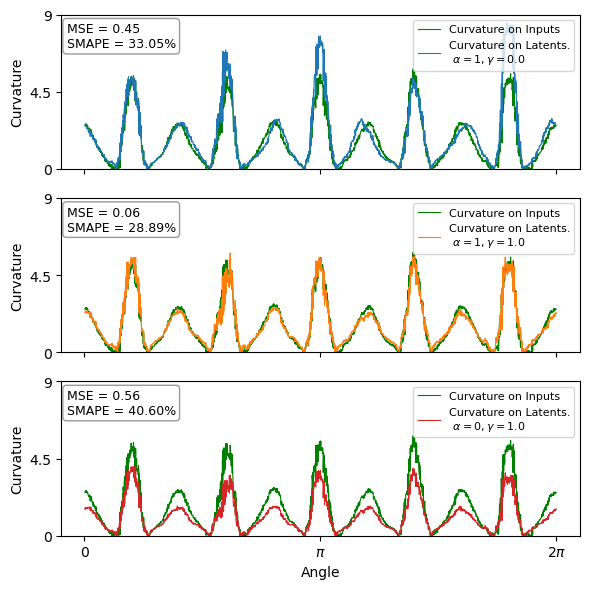

In [9]:
base_path = "OLD_notebooks_euclid_ae/curvatures/"
file_paths = [
    "curvatures_exp00_ae_flower_curve_w100_b64_for_plotting.pt",
    "curvatures_exp01_ae_flower_curve_w100_b64_for_plotting.pt",
    "curvatures_exp02_ae_flower_curve_w100_b64_for_plotting.pt",
]
labels = [r"$\alpha=1,\gamma=0.0$", r"$\alpha=1,\gamma=1.0$", r"$\alpha=0,\gamma=1.0$"]
save_path = "plots/euclid_ae/euclid_ae_flower_impact_ltopo.png"

plot_curvatures_stacked(base_path=base_path, file_paths=file_paths, labels=labels, ground_truth="emp_curv_ins",
                        save_path=save_path)

# Euclidean AE - Sphere high dim

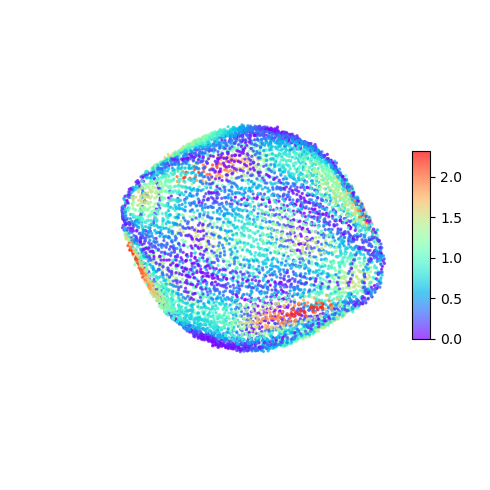

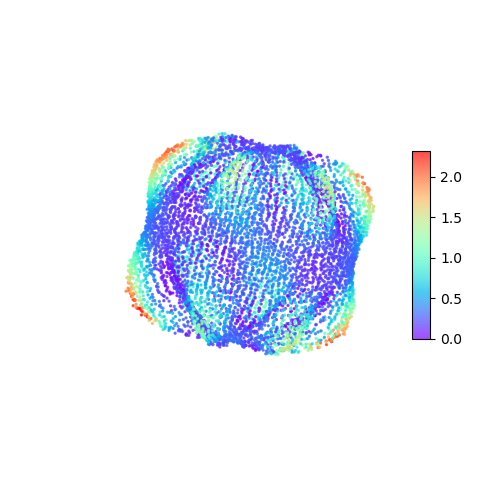

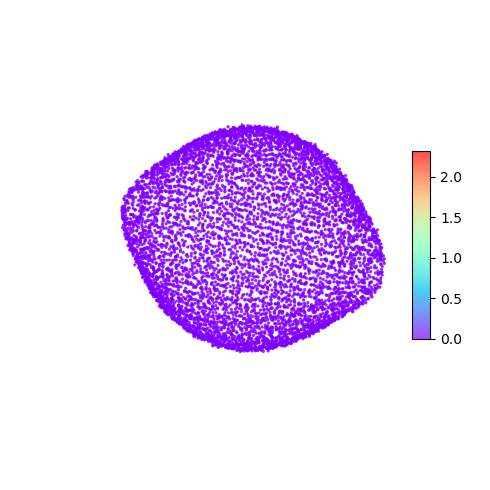

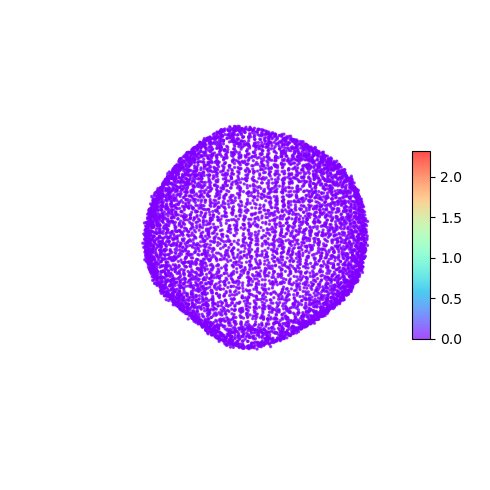

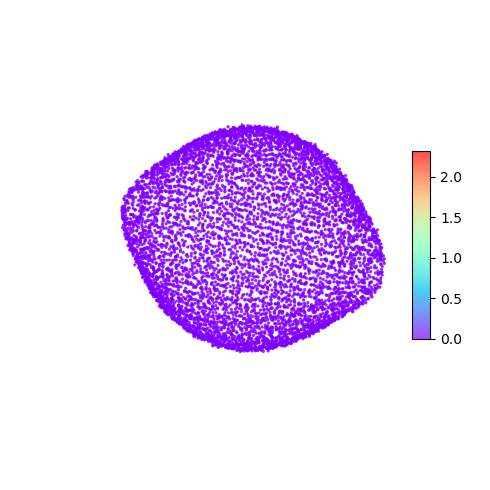

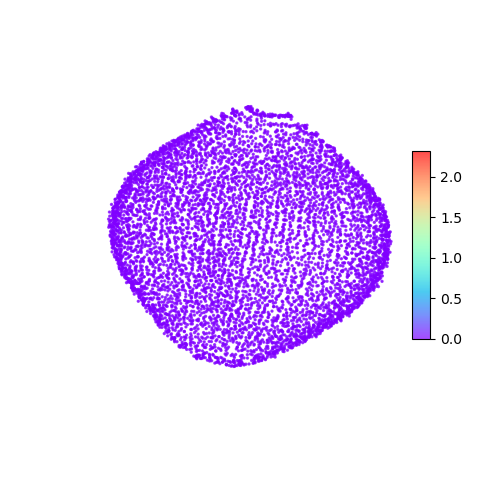

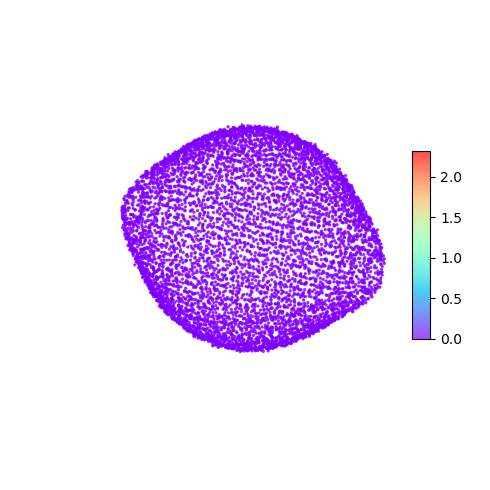

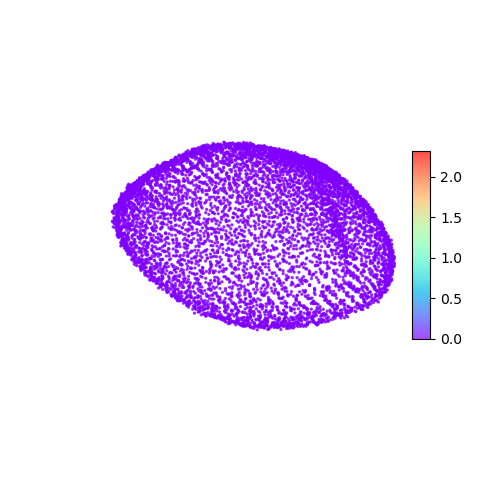

In [10]:
base_path = 'OLD_notebooks_euclid_ae/curvatures/'
file_paths = [
    'curvatures_exp04_sphere_high_for_plotting.pt',
    'curvatures_exp01_sphere_high_for_plotting.pt',
    'curvatures_exp02_sphere_high_for_plotting.pt',
    'curvatures_exp03_sphere_high_for_plotting.pt',
]

plot_curvature_heatmaps(
     base_path_curv=base_path,
     file_paths=file_paths,
     save_path='plots/',
     plot_empirical=True,
     plot_pullback=False,
     dataset_name='sp',
     show_plot=True
)

# plot_curvatures_2d(
#     base_path=base_path,
#     file_paths=file_paths,
#     save_path='plots/',
#     plot_empirical=True,
#     plot_pullback=False,
#     dataset_name='sphere',
#     show_plot=True
# )

In [24]:
base_path = 'OLD_notebooks_euclid_ae/curvatures/'
file_paths = [
    'curvatures_exp00_sphere_high_dim_new_version.pt',
]

plot_curvature_heatmaps(
     base_path_curv=base_path,
     file_paths=file_paths,
     save_path='plots/',
     plot_empirical=True,
     plot_pullback=False,
     dataset_name='sp',
     show_plot=True
)

# plot_curvatures_2d(
#     base_path=base_path,
#     file_paths=file_paths,
#     save_path='plots/',
#     plot_empirical=True,
#     plot_pullback=False,
#     dataset_name='sphere',
#     show_plot=True
# )

KeyError: 'points'

# Euclidean AE - Torus high dim

In [11]:
base_path = 'OLD_notebooks_euclid_ae/curvatures/'
file_paths = [
    'curvatures_exp00_torus_high_dim.pt',
    'curvatures_exp03_torus_high_dim.pt',
    'curvatures_exp06_torus_high_dim.pt',
    'curvatures_exp09_torus_high_dim.pt',

]

plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path='plots/',
    plot_empirical=True,
    plot_pullback=False,
    dataset_name='torus',
    show_plot=True
)

plot_curvatures_2d(
    base_path=base_path,
    file_paths=file_paths,
    save_path='plots/',
    plot_empirical=True,
    plot_pullback=False,
    dataset_name='torus',
    show_plot=True
)

KeyError: 'points'

# Euclid AE Torus low dim

In [12]:
base_path = 'OLD_notebooks_euclid_ae/curvatures/'
file_paths = [
    'curvatures_exp00_ae_t2_synthetic_w100_b64.pt',
    'curvatures_exp03_ae_t2_synthetic_w100_b64.pt',
    'curvatures_exp06_ae_t2_synthetic_w100_b64.pt',
    'curvatures_exp09_ae_t2_synthetic_w100_b64.pt',

]

plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path='plots/',
    plot_empirical=True,
    plot_pullback=False,
    dataset_name='torus',
    show_plot=True
)

KeyError: 'points'

# M-VAE Torus high dim

In [ ]:
base_path = 'OLD_notebooks_m_vae/curvatures/'
file_paths = [
    'curvatures_exp00_vmf_torus_high_dim_try_pullback.pt',
]

plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path='plots/',
    plot_empirical=False,
    plot_pullback=True,
    dataset_name='torus',
    show_plot=True
)

# M-VAE Sphere high dim

In [ ]:
base_path = 'OLD_notebooks_m_vae/curvatures/'
file_paths = [
    'curvatures_exp00_vae_sphere_high_dim.pt',
    'curvatures_exp01_vae_sphere_high_dim.pt',
    'curvatures_exp02_vae_sphere_high_dim.pt',
    'curvatures_exp04_vae_sphere_high_dim.pt',
    'curvatures_exp10_vae_sphere_high_dim.pt',
    'curvatures_exp16_vae_sphere_high_dim.pt',
]

plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path='plots/mvae',
    plot_empirical=False,
    plot_pullback=True,
    dataset_name='sphere',
    show_plot=True
)